Taavon Peoples QML Project

Data Encoding

In [26]:
# If you have not already, install scikit learn
%pip install scikit-learn
%pip install qiskit
%pip install qiskit-aer --quiet
%pip install pylatexenc
%pip install matplotlib
%pip install qiskit-ibm-runtime
%pip install qiskit-ibm-transpiler

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
import sys
from pathlib import Path
import importlib

# add project root (current working dir or nearest parent containing utils.py) to sys.path and import utils
cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [28]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
     token="yZoR4zRA8X7ZX2rauN_pkmyBrId1CJbbXR1RoN_dFvJh",
     set_as_default = True
     )

AccountAlreadyExistsError: 'Named account (default-ibm-quantum-platform) already exists. Set overwrite=True to overwrite.'

Step 1 Data Encoding
Map inputs to quantum circuit

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from utils import init

# This only needs to be run once, as the dataset is cached after the first run
dataset = init()

print(dataset["Black"][:20])

Need to adjust the data for training
pre-processing needed here

Should adjust the data as follows for the initial test
Set each value as a percentage of the total, use that to predict the NO2 level or PM25 levels

Each Demographic is a feature here (Black, Whtie, Hispanic, etc)

In [38]:
dataset

,CUA,City,GEOID,Grade,PHOLC,Asian,Black,Hispanic,White,Other,Total,NO2,PM25
0,"Birmingham, AL","Birmingham, AL",010730047022054,A,0.825306,1,0,0,37,0,38,7.57483,11.4920
1,"Birmingham, AL","Birmingham, AL",010730047022056,A,1.000000,1,1,1,226,3,232,6.62932,11.3328
2,"Birmingham, AL","Birmingham, AL",010730048002010,A,0.266178,2,0,1,23,2,28,9.36228,12.4717
3,"Birmingham, AL","Birmingham, AL",010730048002011,A,0.721972,1,0,0,30,0,31,9.07123,12.3103
4,"Birmingham, AL","Birmingham, AL",010730048002015,A,0.284738,1,0,0,63,0,64,8.49492,12.3611
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023723,"York, PA",NA,421330016001012,N,1.000000,0,0,0,0,2,2,13.82110,11.5294
2023724,"York, PA",NA,421330210205027,N,1.000000,0,0,0,0,2,2,7.14514,10.8432
2023725,"York, PA",NA,421330214101019,N,1.000000,0,0,0,0,1,1,10.00050,10.1784
2023726,"Youngstown, OH--PA",NA,420850332001040,N,1.000000,0,0,0,0,1,1,10.66550,11.4327


In [39]:
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 2023728 entries, 0 to 2023727
Data columns (total 13 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CUA       str    
 1   City      str    
 2   GEOID     str    
 3   Grade     str    
 4   PHOLC     float64
 5   Asian     int64  
 6   Black     int64  
 7   Hispanic  int64  
 8   White     int64  
 9   Other     int64  
 10  Total     int64  
 11  NO2       float64
 12  PM25      float64
dtypes: float64(3), int64(6), str(4)
memory usage: 200.7 MB
None


In [60]:
# Format the data for the first 10 rows, to be used as input to the quantum machine learning model
subset = dataset.head(10)

array_stacked = np.column_stack([subset[col].values for col in ['Other', 'Asian', 'Black', 'White', 'Hispanic', 'Total', 'NO2']])

processed_data = list()
for row in array_stacked:
    processed_data.append([row[0] / row[5], row[1] / row[5], row[2] / row[5], row[3] / row[5], row[4] / row[5], row[6]])

print(processed_data) 

[[np.float64(0.0), np.float64(0.02631578947368421), np.float64(0.0), np.float64(0.9736842105263158), np.float64(0.0), np.float64(7.57483)], [np.float64(0.01293103448275862), np.float64(0.004310344827586207), np.float64(0.004310344827586207), np.float64(0.9741379310344828), np.float64(0.004310344827586207), np.float64(6.62932)], [np.float64(0.07142857142857142), np.float64(0.07142857142857142), np.float64(0.0), np.float64(0.8214285714285714), np.float64(0.03571428571428571), np.float64(9.36228)], [np.float64(0.0), np.float64(0.03225806451612903), np.float64(0.0), np.float64(0.967741935483871), np.float64(0.0), np.float64(9.07123)], [np.float64(0.0), np.float64(0.015625), np.float64(0.0), np.float64(0.984375), np.float64(0.0), np.float64(8.49492)], [np.float64(0.0), np.float64(0.1484375), np.float64(0.1328125), np.float64(0.703125), np.float64(0.015625), np.float64(9.28256)], [np.float64(0.019672131147540985), np.float64(0.036065573770491806), np.float64(0.28524590163934427), np.float64(

circuit depth =  9


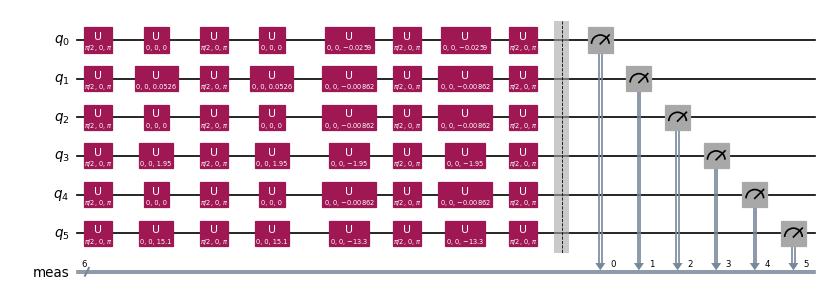

In [61]:
from qiskit.circuit.library import z_feature_map
from qiskit.circuit.library import unitary_overlap

# Data points with labels removed, for inner product
#train_data = [dataset["Black"][:10], dataset["White"][:10]]
train_data=[processed_data[0], processed_data[1]]

# Encode the data into quantum states using the ZFeatureMap
fm = z_feature_map(feature_dimension=np.shape(train_data)[1])

#Assign Params
unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

Step 2
Optimize the circuit for execution

In [54]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    # NOTE: Using Simulator for testing, for speed
    operational=True, simulator=False, min_num_qubits=fm.num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-03-14 13:44:23,307: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open, pay-as-you-go), the available account instances are: open-instance, paid-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-14 13:44:24,622: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-14 13:44:26,076: Loading instance: paid-instance, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-03-14 13:44:30,374: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


In [55]:
# Apply level 3 optimization to our overlap circuit
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

print("circuit depth = ", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)

circuit depth =  10


1

Step 3: Execute the circuit

In [56]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Options, Session, Sampler

num_shots = 10000

# Evaluate the problem using state vector-based primitives from Qiskit
sampler = StatevectorSampler()
results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

The cell below is  for real QC execution. Create methods for this 

In [ ]:
# Benchmarked on an Eagle processor, 7-11-24, took 4 sec.
#this is to execure on a real machine
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

num_shots = 10000

# Use sampler and get the counts

sampler = Sampler(mode=backend)
#this one is using the overlap_ibm circuit instead of overlap_circ
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

Convert answer back to classical by reading the 0 bit

In [57]:
counts.get(0, 0.0) / num_shots



0.9992

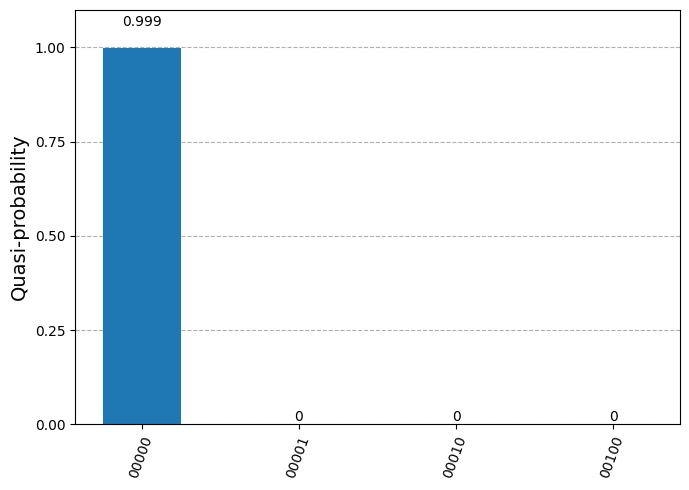

In [58]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)


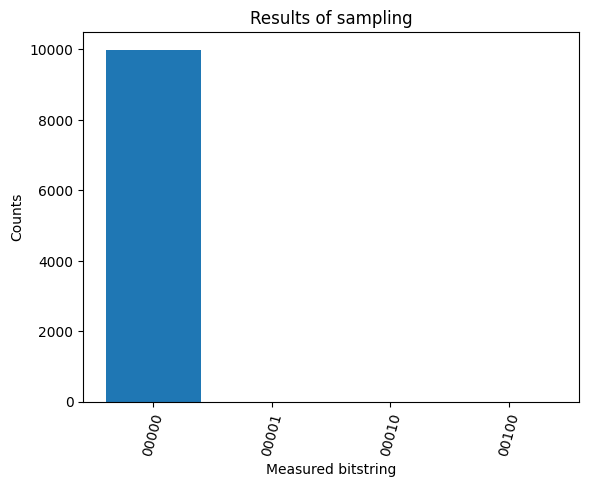

In [59]:
def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()


visualize_counts(counts, overlap_circ.num_qubits)